# Chihuahua vs Muffin : Classifieur

Dataset : [Kaggle - samuelcortinhas](https://www.kaggle.com/datasets/samuelcortinhas/muffin-vs-chihuahua-image-classification)

~6 000 images, classification binaire avec ResNet18 + Transfer Learning.

In [1]:
# ── Cellule 1 : Install
!pip install -q torch torchvision timm albumentations tqdm

In [ ]:
# ── Cellule 2 : Config
from pathlib import Path

CFG = {
    'data_dir'     : Path('dataset'),
    'img_size'     : 224,
    'batch_size'   : 32,
    'epochs'       : 15,
    'lr'           : 3e-4,
    'weight_decay' : 1e-4,
    'patience'     : 5,
    'amp'          : True,
    'ckpt_path'    : Path('checkpoints/best.pth'),
    'num_workers'  : 2,
}

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
CFG['ckpt_path'].parent.mkdir(exist_ok=True)

Device : cuda


In [ ]:
# Vérifie la structure
for split in ['train', 'test']:
    for cls in ['chihuahua', 'muffin']:
        p = CFG['data_dir'] / split / cls
        n = len(list(p.glob('*'))) if p.exists() else 0
        print(f'{split}/{cls} : {n} images')

train/chihuahua : 2559 images
train/muffin : 2174 images
test/chihuahua : 640 images
test/muffin : 544 images


In [4]:
# ── Cellule 4 : Dataset & Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader

MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

train_tf = A.Compose([
    A.Resize(CFG['img_size'], CFG['img_size']),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Rotate(limit=15, p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(CFG['img_size'], CFG['img_size']),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

CLASSES = ['chihuahua', 'muffin']  # 0 = chihuahua, 1 = muffin

class ChihuahuaDataset(Dataset):
    def __init__(self, root, transform):
        self.samples = []
        for label, cls in enumerate(CLASSES):
            for p in (root / cls).glob('*'):
                if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'}:
                    self.samples.append((p, label))
        self.transform = transform

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)['image']
        return img, label

train_ds = ChihuahuaDataset(CFG['data_dir'] / 'train', train_tf)
val_ds   = ChihuahuaDataset(CFG['data_dir'] / 'test',  val_tf)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)

print(f'Train : {len(train_ds)} images | Val : {len(val_ds)} images')

Train : 4733 images | Val : 1184 images


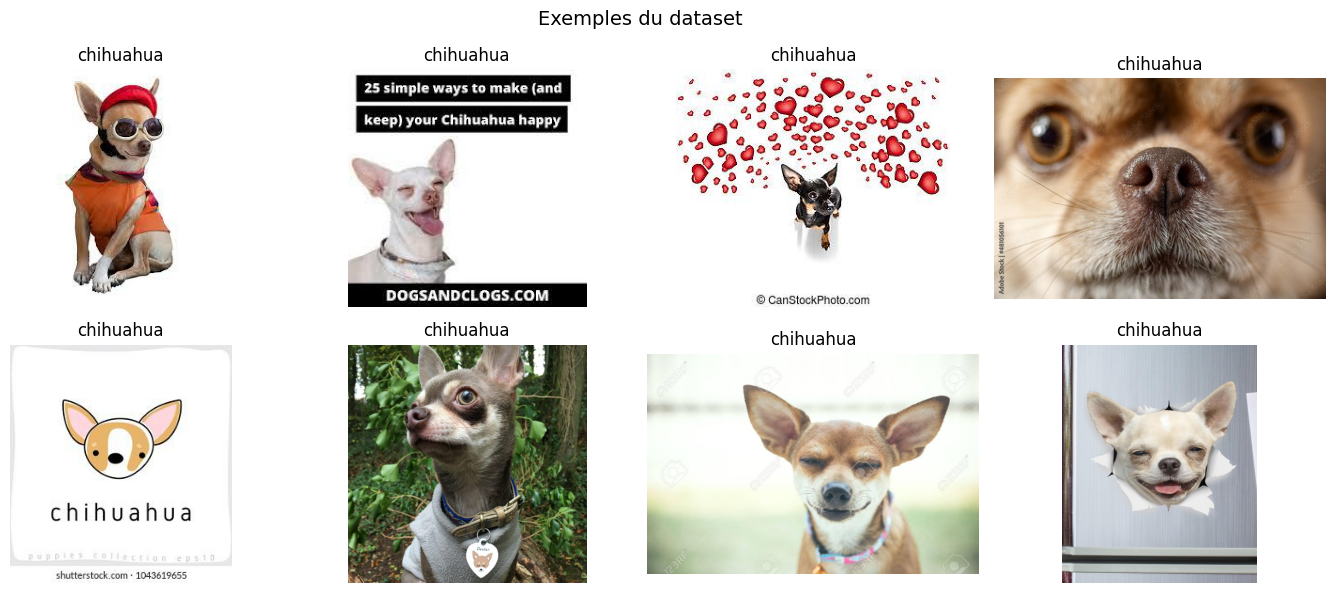

In [ ]:
# ── Cellule 5 : Visualiser 8 exemples
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Exemples du dataset', fontsize=14)
for i, (path, label) in enumerate(train_ds.samples[:8]):
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    axes[i//4][i%4].imshow(img)
    axes[i//4][i%4].set_title(CLASSES[label])
    axes[i//4][i%4].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ── Cellule 6 : Modèle — ResNet18 pré-entraîné + tête de classification
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(weights='IMAGENET1K_V1')

# Remplacer la dernière couche (1000 classes ImageNet) par une couche binaire
model.fc = nn.Linear(model.fc.in_features, 1)  # 1 sortie = probabilité chihuahua vs muffin

model = model.to(device)
print(f'Paramètres : {sum(p.numel() for p in model.parameters())/1e6:.1f}M')
print(f'Dernière couche : {model.fc}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/do5-ajlp/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:00<00:00, 73.1MB/s]


Paramètres : 11.2M
Dernière couche : Linear(in_features=512, out_features=1, bias=True)


In [ ]:
# ── Cellule 7 : Entraînement
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm

loss_fn   = nn.BCEWithLogitsLoss()
optimizer = AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
scaler    = torch.cuda.amp.GradScaler(enabled=CFG['amp'])

best_acc   = 0.0
no_improve = 0
history    = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, CFG['epochs'] + 1):
    # ── Train
    model.train(); train_loss = 0
    for imgs, labels in tqdm(train_loader, desc=f'Ep {epoch:02d} train'):
        imgs   = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)  # (B,) → (B,1) float
        optimizer.zero_grad()
        with torch.autocast('cuda', enabled=CFG['amp']):
            loss = loss_fn(model(imgs), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Val
    model.eval(); val_loss = 0; correct = 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'Ep {epoch:02d} val  '):
            imgs   = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            logits = model(imgs)
            val_loss += loss_fn(logits, labels).item()
            preds    = (torch.sigmoid(logits) > 0.5).float()
            correct  += (preds == labels).sum().item()
    val_loss /= len(val_loader)
    val_acc   = correct / len(val_ds)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Ep {epoch:02d} | train={train_loss:.4f} | val={val_loss:.4f} | acc={val_acc:.4f}')

    if val_acc > best_acc:
        best_acc = val_acc; no_improve = 0
        torch.save({'epoch': epoch, 'val_acc': val_acc,
                    'state_dict': model.state_dict()}, CFG['ckpt_path'])
        print(f'  ✓ Best checkpoint (acc={best_acc:.4f})')
    else:
        no_improve += 1
        if no_improve >= CFG['patience']:
            print(f'Early stopping à epoch {epoch}'); break

print(f'\nDone. Best val acc : {best_acc:.4f}')

/tmp/ipykernel_1953118/2063369821.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=CFG['amp'])
Ep 01 val  : 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:03<00:00, 11.46it/s]


Ep 01 | train=0.0679 | val=0.0225 | acc=0.9932
  ✓ Best checkpoint (acc=0.9932)


Ep 02 val  : 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:03<00:00, 12.13it/s]


Ep 02 | train=0.0323 | val=0.0237 | acc=0.9941
  ✓ Best checkpoint (acc=0.9941)


Ep 03 val  : 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:02<00:00, 13.86it/s]


...

Ep 11 | train=0.0015 | val=0.0041 | acc=0.9983


Ep 12 val  : 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:02<00:00, 15.58it/s]


Ep 12 | train=0.0006 | val=0.0049 | acc=0.9983


Ep 13 val  : 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:02<00:00, 16.13it/s]

Ep 13 | train=0.0007 | val=0.0064 | acc=0.9983
Early stopping à epoch 13

✅ Done. Best val acc : 0.9983


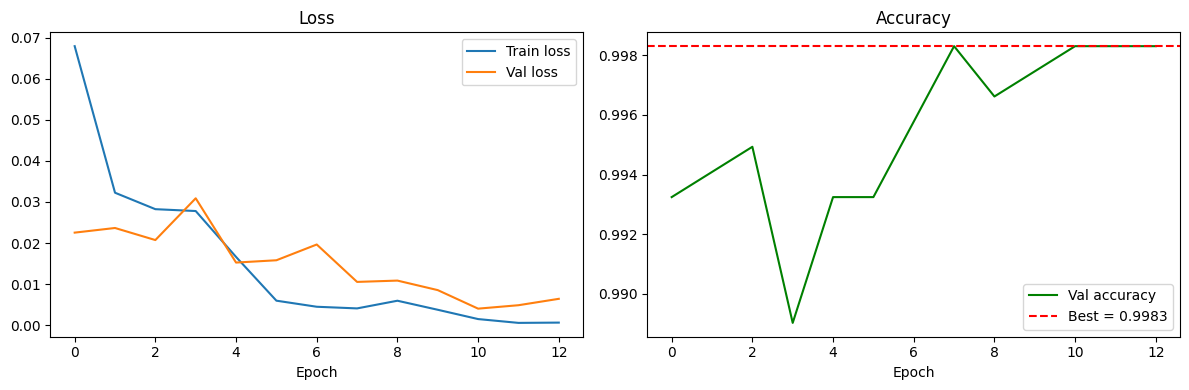

In [8]:
# ── Cellule 8 : Courbes d'entraînement
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train loss')
ax1.plot(history['val_loss'],   label='Val loss')
ax1.set_title('Loss'); ax1.legend(); ax1.set_xlabel('Epoch')

ax2.plot(history['val_acc'], color='green', label='Val accuracy')
ax2.set_title('Accuracy'); ax2.legend(); ax2.set_xlabel('Epoch')
ax2.axhline(best_acc, color='red', linestyle='--', label=f'Best = {best_acc:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [9]:
# ── Cellule 9 : Évaluation finale + matrice de confusion
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

ckpt = torch.load(CFG['ckpt_path'], map_location=device)
model.load_state_dict(ckpt['state_dict'])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        logits = model(imgs.to(device))
        preds  = (torch.sigmoid(logits) > 0.5).long().cpu().squeeze(1)
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print(classification_report(all_labels, all_preds, target_names=CLASSES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.title('Matrice de confusion')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout(); plt.show()

ModuleNotFoundError: No module named 'seaborn'

→ muffin (100.0% confiance)


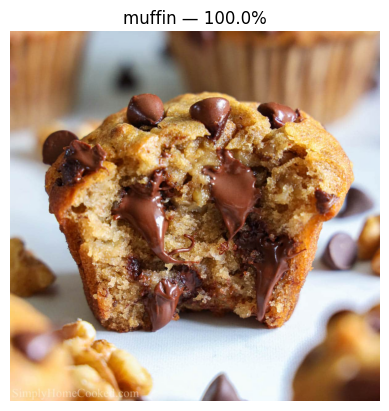

→ chihuahua (100.0% confiance)


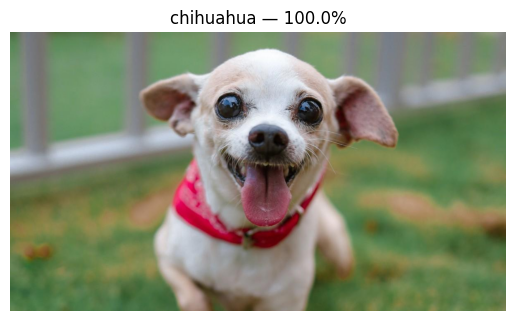

→ chihuahua (100.0% confiance)


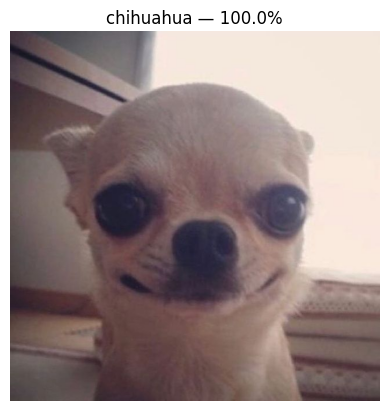

→ chihuahua (100.0% confiance)


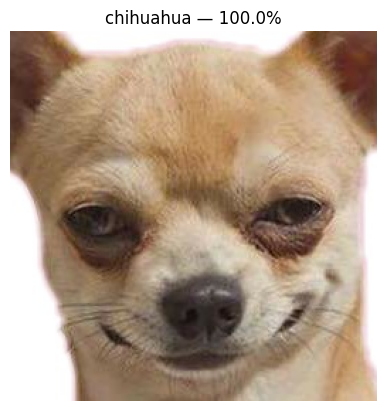

→ chihuahua (99.4% confiance)


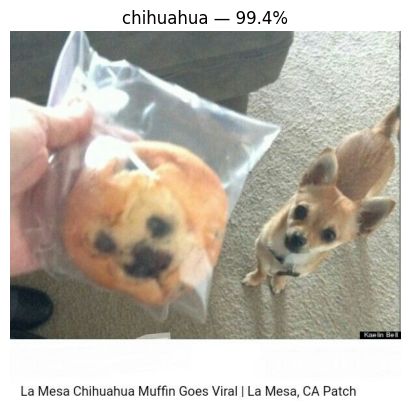

→ chihuahua (99.4% confiance)


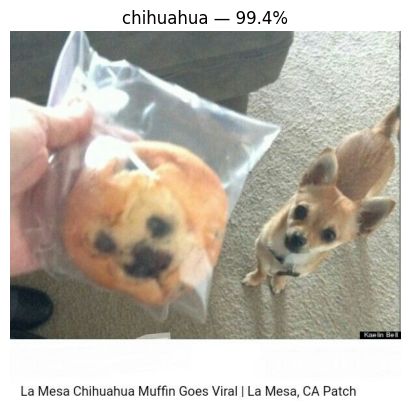

→ chihuahua (94.7% confiance)


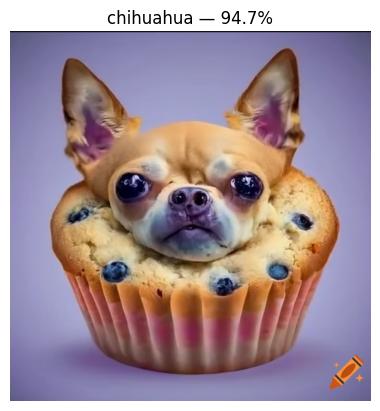

'chihuahua'

In [ ]:
# ── Cellule 10 : Inférence sur une image
def predict(img_path: str) -> str:
    img   = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    t     = val_tf(image=img)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        prob  = torch.sigmoid(model(t)).item()
    label = CLASSES[int(prob > 0.5)]
    conf  = prob if prob > 0.5 else 1 - prob
    print(f'→ {label} ({conf*100:.1f}% confiance)')
    plt.imshow(img); plt.title(f'{label} — {conf*100:.1f}%'); plt.axis('off'); plt.show()
    return label

predict('test.jpg')
predict('test2.jpg')
predict('test3.jpg')
predict('test4.jpg')
predict('test5.jpg')
predict('test5.jpg')
predict('test6.png')